# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

## 2. Datos

In [19]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [20]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [21]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [22]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
laptop_ID,int64,0.0,912,100.0
Company,object,0.0,19,2.08
Product,object,0.0,480,52.63
TypeName,object,0.0,6,0.66
Inches,float64,0.0,17,1.86
ScreenResolution,object,0.0,36,3.95
Cpu,object,0.0,107,11.73
Ram,object,0.0,9,0.99
Memory,object,0.0,37,4.06
Gpu,object,0.0,93,10.2


### 2.2 Definir X e y


In [23]:
target = 'Price_in_euros'
X = df.drop(columns=target)
y = df[target]

### 2.3 Dividir en train y test

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [25]:
# 2. Eliminar outliers del target solo en train
mask = y_train <= 3000
X_train = X_train[mask]
y_train = y_train[mask]

In [26]:
def feature_engineering(df):
    df = df.copy()

    # Ram y Weight (Eliminamos 'GB' y 'kg' y nos quedamos con los números pasandolos a entero y float respectivamente)
    df['Ram_GB'] = df['Ram'].str.replace('GB', '').astype(int)
    df['Weight_kg'] = df['Weight'].str.replace('kg', '').astype(float)

    # CPU (Nos vamos a quedar con fabricante, modelo, velocidad y generación del procesador)
    df['Cpu_brand'] = df['Cpu'].str.split().str[0]  # Intel / AMD
    df['Cpu_tier'] = df['Cpu'].str.extract(r'(i3|i5|i7|i9|Pentium|Celeron|Ryzen|Atom)', flags=re.IGNORECASE)[0].str.lower()
    df['Cpu_ghz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz')[0].astype(float)
    df['Cpu_gen'] = df['Cpu'].str.extract(r'i[3579]\s(\d)\d{3}')[0].astype(float)
    df['Cpu_gen'] = df['Cpu_gen'].fillna(0)
    

    # GPU (Nos quedamos con el fabricante y los modelos de Nvidia)
    df['Gpu_brand'] = df['Gpu'].str.split().str[0]  # Intel / Nvidia / AMD
    df['Gpu_nvidia_model'] = df['Gpu'].str.extract(r'(?:GTX|GT|MX|Quadro M)\s?(\d+)')[0].astype(float)
    df['Gpu_nvidia_model'] = df['Gpu_nvidia_model'].fillna(0)

    # Memory(Nos quedamos si es dual, con la capacidad del primer disco + tipo)
    df['Memory_GB'] = df['Memory'].str.extract(r'(\d+\.?\d*)(?:GB|TB)')[0].astype(float)
    df['Memory_is_TB'] = df['Memory'].str.contains(r'^\d+\.?\d*TB').astype(int)
    df['Memory_GB'] = df.apply(lambda r: r['Memory_GB'] * 1024 if r['Memory_is_TB'] else r['Memory_GB'], axis=1)
    df['Memory_type'] = df['Memory'].str.extract(r'(SSD|HDD|Flash|Hybrid)', flags=re.IGNORECASE)[0].str.upper()
    df['Memory_type'] = df['Memory_type'].fillna('Other')
    df['Memory_dual'] = df['Memory'].str.contains(r'\+').astype(int)

    # Screen (Nos quedamos con el ancho y la altura de la pantalla, calculamos pixeles por pulgada,y creamos dos variables binarias para indicar si es táctil o IPS)
    df['Screen_width'] = df['ScreenResolution'].str.extract(r'(\d{3,4})x\d{3,4}')[0].astype(float)
    df['Screen_height'] = df['ScreenResolution'].str.extract(r'\d{3,4}x(\d{3,4})')[0].astype(float)
    df['Screen_ppi'] = ((df['Screen_width']**2 + df['Screen_height']**2)**0.5) / df['Inches']
    df['Is_touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen', case=False).astype(int)
    df['Is_IPS'] = df['ScreenResolution'].str.contains('IPS', case=False).astype(int)

    # Drop originales
    df = df.drop(columns=['Ram', 'Weight', 'Product', 'Cpu', 'Gpu', 'Memory', 'ScreenResolution', 'Memory_is_TB'])

    return df

In [27]:
# Feature engineering por separado
X_train = feature_engineering(X_train)
X_test  = feature_engineering(X_test)

# Exploración sobre X_train + y_train juntos
df_train = X_train.copy()
df_train['Price_in_euros'] = y_train.values

In [28]:
# Relación numéricas vs target
num_cols = get_features_num_regression(df_train, target_col='Price_in_euros', umbral_corr=0.1, pvalue=0.05)
num_cols

['Ram_GB',
 'Cpu_ghz',
 'Cpu_gen',
 'Gpu_nvidia_model',
 'Memory_GB',
 'Memory_dual',
 'Screen_width',
 'Screen_height',
 'Screen_ppi',
 'Is_touchscreen',
 'Is_IPS']

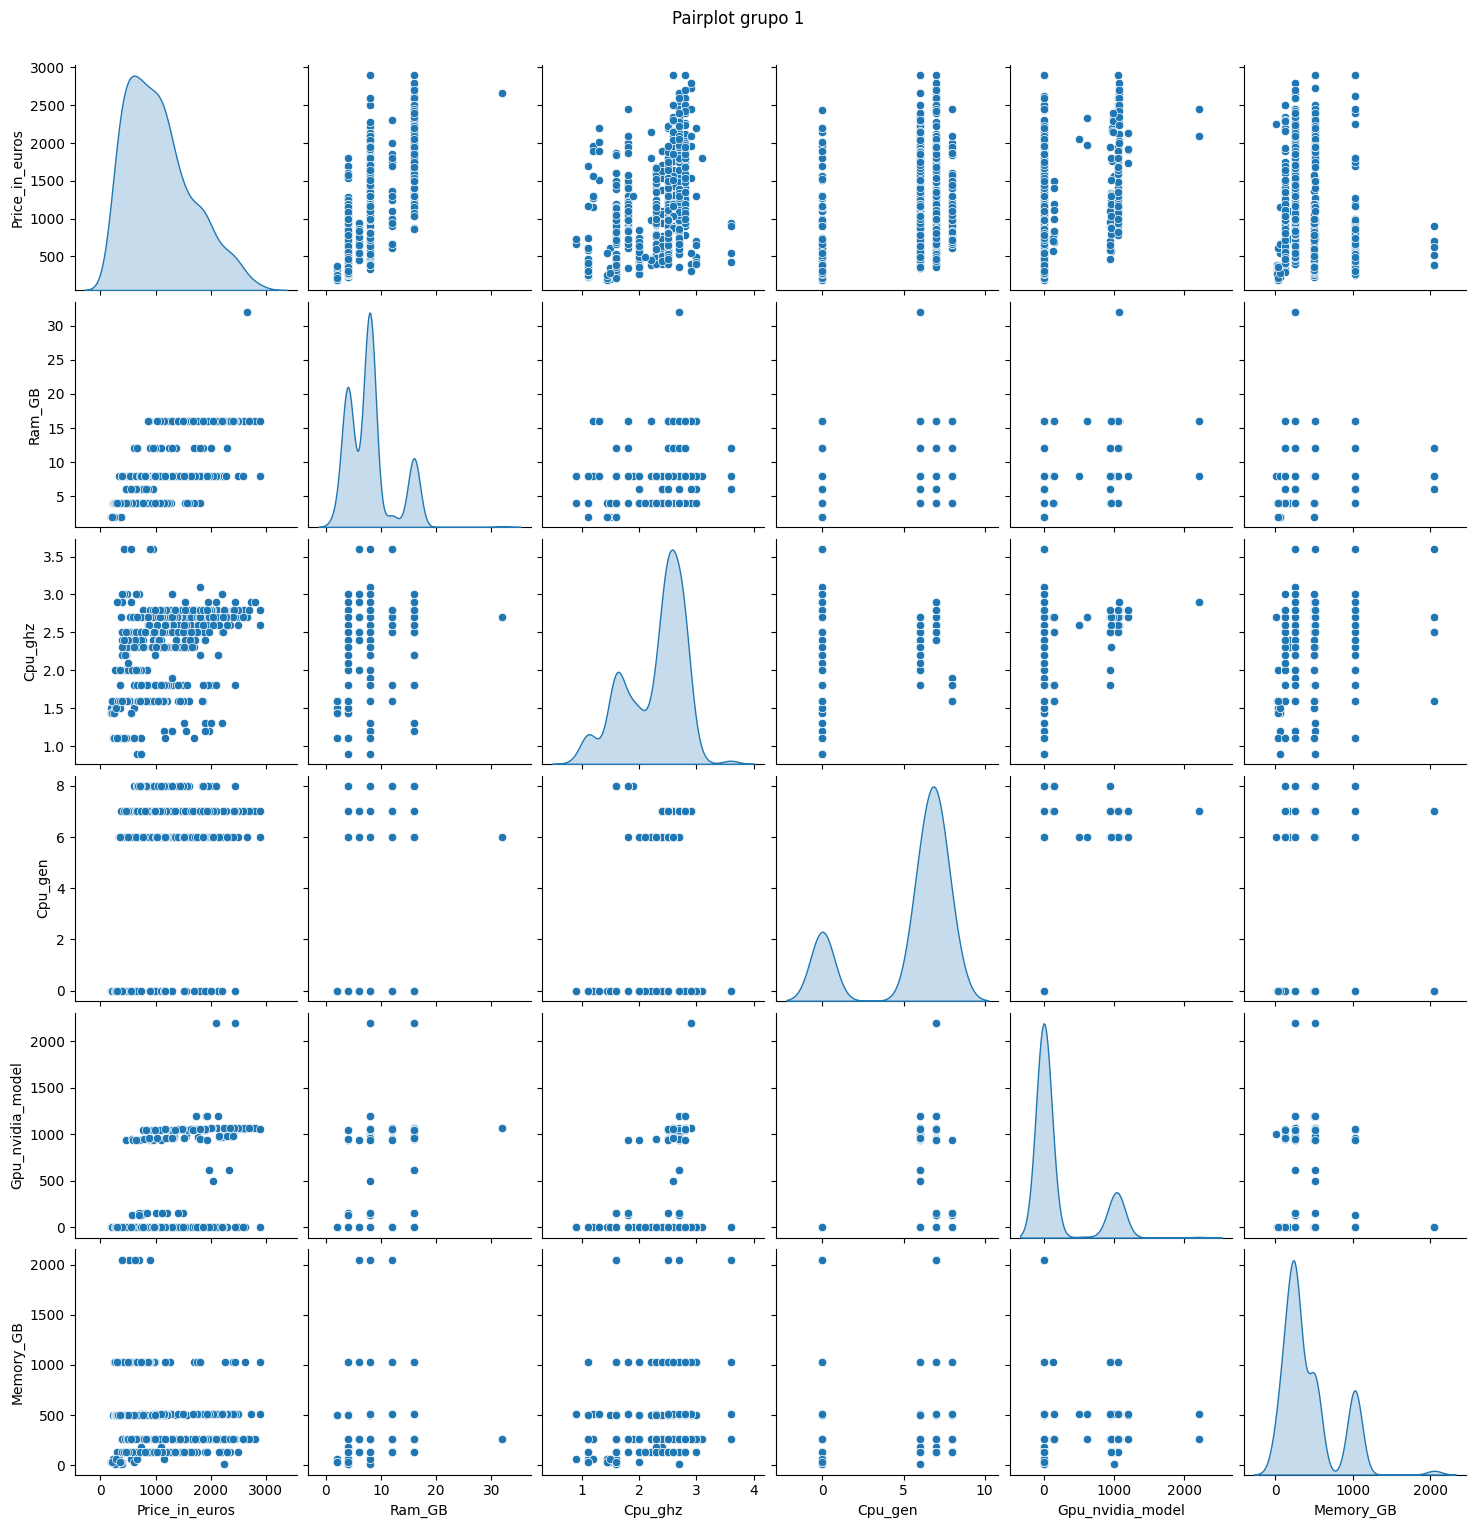

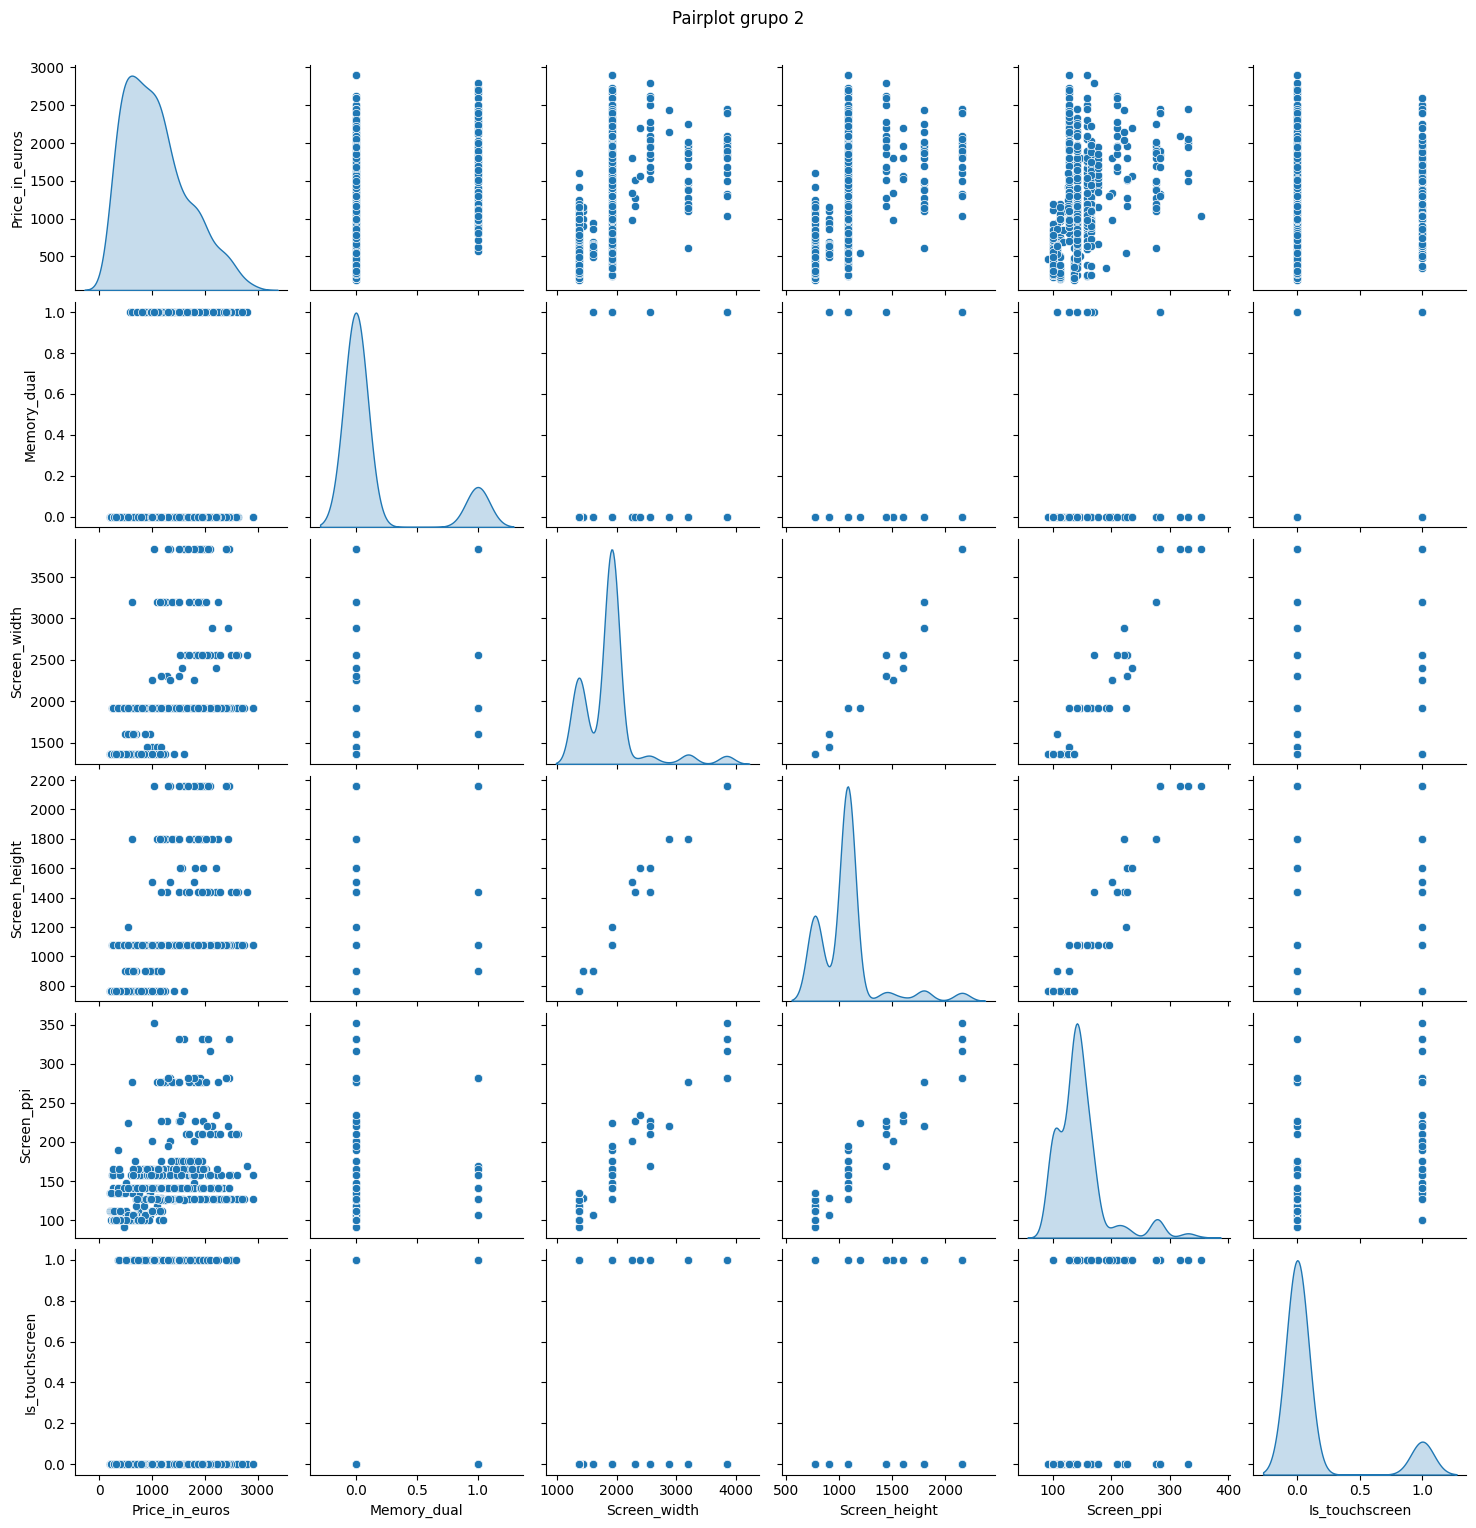

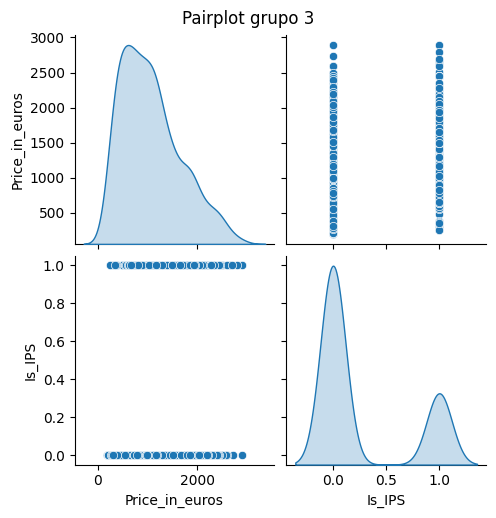

['Ram_GB',
 'Cpu_ghz',
 'Cpu_gen',
 'Gpu_nvidia_model',
 'Memory_GB',
 'Memory_dual',
 'Screen_width',
 'Screen_height',
 'Screen_ppi',
 'Is_touchscreen',
 'Is_IPS']

In [29]:
plot_features_num_regression(df_train, target_col='Price_in_euros', columns=num_cols)

In [30]:
# Relación categóricas vs target
cat_cols = get_features_cat_regression(df_train, target_col='Price_in_euros', pvalue=0.05)
cat_cols

['Company',
 'TypeName',
 'OpSys',
 'Cpu_brand',
 'Cpu_tier',
 'Gpu_brand',
 'Memory_type']

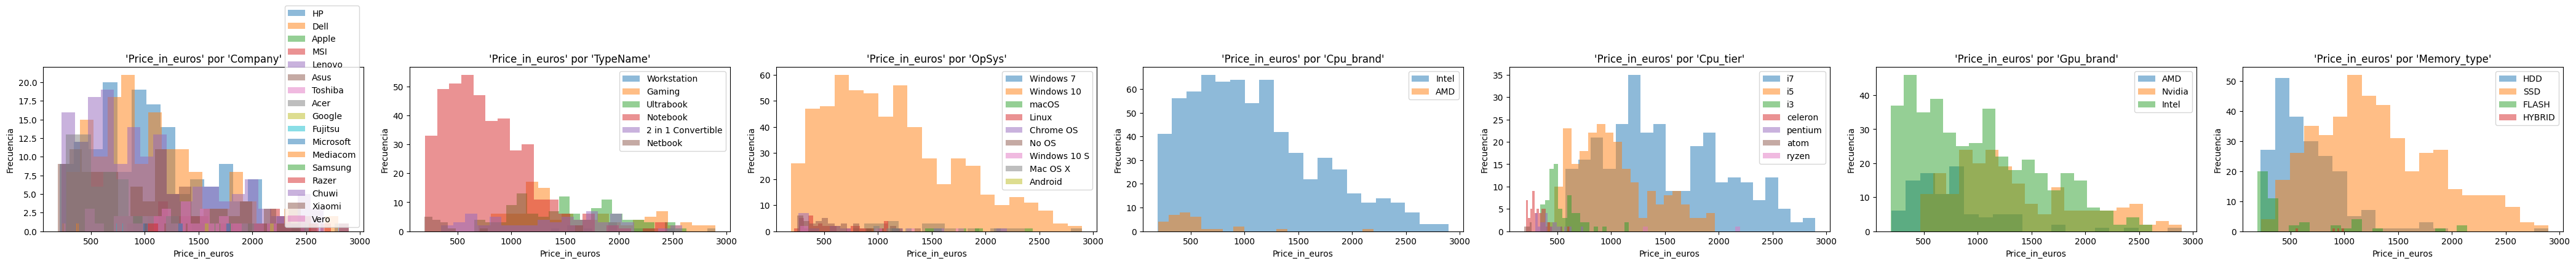

['Company',
 'TypeName',
 'OpSys',
 'Cpu_brand',
 'Cpu_tier',
 'Gpu_brand',
 'Memory_type']

In [31]:
plot_features_cat_regression(df_train, target_col='Price_in_euros', columns=cat_cols)

In [32]:
# Selección de features
features = num_cols + cat_cols

X_train_selec = X_train[features]
X_test_selec = X_test[features]

In [33]:
# Primero vamos a aplicar get_dummies a las variables categóricas

X_train_enc = pd.get_dummies(X_train_selec, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test_selec,  columns=cat_cols)

# Alinear columnas de test con train
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)


In [34]:
# Medir asimetría de las variables numéricas y aplicar transformación a las que proceda
asimetria = X_train[num_cols].skew().sort_values(ascending=False)
print(asimetria)

Is_touchscreen      2.161784
Screen_width        2.093312
Screen_ppi          2.074491
Screen_height       2.034100
Memory_dual         1.890165
Gpu_nvidia_model    1.717865
Memory_GB           1.476997
Ram_GB              1.127887
Is_IPS              1.073669
Cpu_ghz            -0.708882
Cpu_gen            -1.395937
dtype: float64


In [36]:
asimetric_cols = ['Is_touchscreen', 'Ram_GB', 'Screen_width', 'Screen_ppi', 'Screen_height', 'Memory_dual', 'Gpu_nvidia_model', 'Memory_GB']

X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()

for col in asimetric_cols:
    X_train_scaled[col] = np.log1p(X_train_scaled[col])
    X_test_scaled[col]  = np.log1p(X_test_scaled[col])



In [37]:
# Por último procedemos al escalado
escaler = StandardScaler()

X_train_scaled[num_cols] = escaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = escaler.transform(X_test_scaled[num_cols])

## 4. Modelado

### 4.1 Entrenamiento

In [38]:
linear_models = {
    'Ridge':      Ridge(),
    'Lasso':      Lasso(),
    'ElasticNet': ElasticNet(),
}

tree_models = {
    'RandomForest':     RandomForestRegressor(random_state=42, max_depth=10),
    'GradientBoosting': GradientBoostingRegressor(random_state=42, max_depth=5),
    'XGBoost':          XGBRegressor(random_state=42, max_depth=5),
    'LightGBM':         LGBMRegressor(random_state=42, max_depth=10),
    'CatBoost':         CatBoostRegressor(random_state=42, verbose=0, max_depth=5),
}
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'R2':   'r2'
}

results = {}

for name, model in linear_models.items():
    cv = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=scoring)
    rmse = -cv['test_RMSE'].mean()
    r2   = cv['test_R2'].mean()
    results[name] = {'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    print(f'{name:20s} | RMSE: {rmse:.2f} | R2: {r2:.4f}')

for name, model in tree_models.items():
    cv = cross_validate(model, X_train_enc, y_train, cv=5, scoring=scoring)
    rmse = -cv['test_RMSE'].mean()
    r2   = cv['test_R2'].mean()
    results[name] = {'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    print(f'{name:20s} | RMSE: {rmse:.2f} | R2: {r2:.4f}')



Ridge                | RMSE: 307.23 | R2: 0.7294
Lasso                | RMSE: 308.54 | R2: 0.7268
ElasticNet           | RMSE: 347.50 | R2: 0.6547
RandomForest         | RMSE: 245.13 | R2: 0.8269
GradientBoosting     | RMSE: 233.86 | R2: 0.8428
XGBoost              | RMSE: 235.21 | R2: 0.8411
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 148
[LightGBM] [Info] Number of data points in the train set: 576, number of used features: 37
[LightGBM] [Info] Start training from score 1059,391667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [39]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
results_df

,RMSE,R2
CatBoost,215.94,0.8660
GradientBoosting,233.86,0.8428
XGBoost,235.21,0.8411
LightGBM,240.35,0.8344
RandomForest,245.13,0.8269
Ridge,307.23,0.7294
Lasso,308.54,0.7268
ElasticNet,347.50,0.6547


### 4.3 Optimización (up to you 🫰🏻)

In [40]:
param_dist = {
    'max_depth':        [3, 4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'iterations':       [100, 200, 300, 500],
    'l2_leaf_reg':      [1, 3, 5, 7, 10],
    'bagging_temperature': [0, 0.5, 1, 2],
}

catboost = CatBoostRegressor(random_state=42, verbose=0)

search = RandomizedSearchCV(
    catboost,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_enc, y_train)

print("Mejores parámetros:", search.best_params_)
print("Mejor RMSE:", round(-search.best_score_, 2))


Mejores parámetros: {'max_depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 500, 'bagging_temperature': 1}
Mejor RMSE: 214.31


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [41]:
# Cargar train completo
df_full = pd.read_csv('./data/train.csv', encoding='latin-1')

# Feature engineering
X_full = df_full.drop(columns=[target, 'laptop_ID'])
y_full = df_full[target]

X_full = feature_engineering(X_full)

# Selección de features
X_full_selec = X_full[features]

# Encoding
X_full_enc = pd.get_dummies(X_full_selec, columns=cat_cols)

# Reentrenar con los mejores parámetros
best_catboost = CatBoostRegressor(
    max_depth=5,
    learning_rate=0.1,
    l2_leaf_reg=3,
    iterations=500,
    bagging_temperature=0,
    random_state=42,
    verbose=0
)

best_catboost.fit(X_full_enc, y_full)


CatBoostRegressor(bagging_temperature=0, iterations=500, l2_leaf_reg=3, learning_rate=0.1, loss_function='RMSE', max_depth=5, random_state=42, verbose=0)

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [42]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [43]:
# Feature engineering
laptop_ids = X_pred['laptop_ID'].copy()
X_pred = X_pred.drop(columns=['laptop_ID'])
X_pred = feature_engineering(X_pred)

# Selección de features
X_pred_selec = X_pred[features]

# Encoding
X_pred_enc = pd.get_dummies(X_pred_selec, columns=cat_cols)

# Alinear columnas con X_full_enc
X_pred_enc = X_pred_enc.reindex(columns=X_full_enc.columns, fill_value=0)


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [44]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [45]:
y_pred_final = best_catboost.predict(X_pred_enc)

submission = pd.DataFrame({
    'laptop_ID':      laptop_ids.values,
    'Price_in_euros': y_pred_final
})

submission.head()


,laptop_ID,Price_in_euros
0,209,1700.530814
1,1281,292.671673
2,1168,356.911898
3,1231,1054.753085
4,1020,1004.019925


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [46]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [47]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260702_152714.csv'. ¡A Kaggle!
